# Cartoonifying Images and Videos
 Parsa Darban 810100141


# Library

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
import os

# Cartoonify Function

In [19]:
def cartoonify(image, smooth_kernel, sigmaColor, sigmaSpace):
        
    grayScaleImage = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    smoothGrayScale = cv2.medianBlur(grayScaleImage , smooth_kernel)

    getEdge = cv2.adaptiveThreshold(
        smoothGrayScale,
        255, 
        cv2.ADAPTIVE_THRESH_MEAN_C, 
        cv2.THRESH_BINARY, 
        9, 
        9 
    )


    colorImage = cv2.bilateralFilter(
        image,
        9,    
        sigmaColor,   
        sigmaSpace    
     )


    cartoonImage = cv2.bitwise_and(colorImage, colorImage, mask=getEdge)

    return cartoonImage

# Cartoonifying Images

(-0.5, 599.5, 749.5, -0.5)

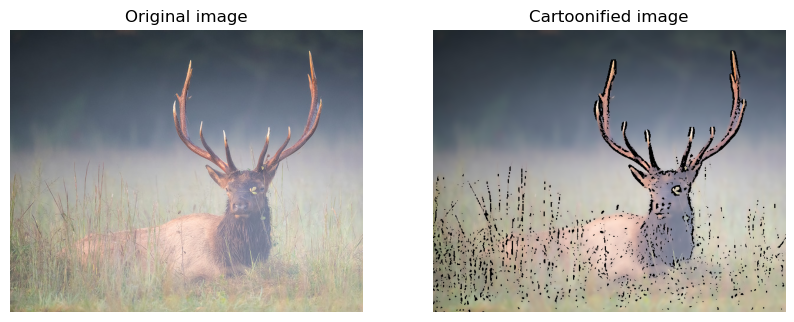

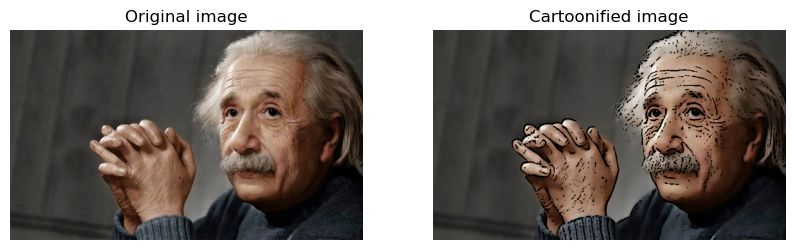

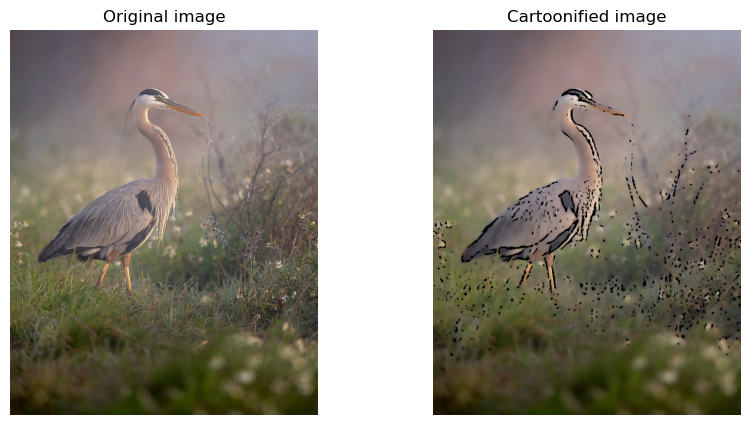

In [20]:
image_path1 = os.path.join("images", "elk.jpg")
image_path2 = os.path.join("images", "Einstein.jpeg")
image_path3 = os.path.join("images", "heron.jpg")

image1 =cv2.imread(image_path1)
image2 =cv2.imread(image_path2)
image3 =cv2.imread(image_path3)

image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
image3 = cv2.cvtColor(image3, cv2.COLOR_BGR2RGB)

result1 = cartoonify(image1, 3, 50, 50)
result2 = cartoonify(image2, 3, 50, 50)
result3 = cartoonify(image3, 5, 200, 200)

# Create a figure to display the images
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(image1)
plt.title("Original image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result1)
plt.title("Cartoonified image")
plt.axis("off")

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(image2)
plt.title("Original image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result2)
plt.title("Cartoonified image")
plt.axis("off")

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(image3)
plt.title("Original image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result3)
plt.title("Cartoonified image")
plt.axis("off")

# Cartoonify Webcam Video Stream

In [21]:
def visualize_fps(image, fps: int):
    
    if len(np.shape(image)) < 3:
        text_color = (255, 255, 255)  
    else:
        text_color = (0, 255, 0) 
   
    row_size = 20 
    left_margin = 24 
    font_size = 1
    font_thickness = 2

    fps_text = "FPS = {:.1f}".format(fps)
    text_location = (left_margin, row_size)
    
    cv2.putText(
        image,
        fps_text,
        text_location,
        cv2.FONT_HERSHEY_PLAIN,
        font_size,
        text_color,
        font_thickness,
    )

    return image


In [22]:
CAMERA_DEVICE_ID = 0 
IMAGE_WIDTH = 800  
IMAGE_HEIGHT = 600  
FRAME_RATE = 30  
DURATION = 1 / FRAME_RATE 

if __name__ == "__main__":
    try:
        cap = cv2.VideoCapture(CAMERA_DEVICE_ID)  

        while cap.isOpened(): 
            start_time = time.time()  
            ret, frame = cap.read()  
            if not ret:
                break  

            frame = cartoonify(frame , 7 , 150 , 150)  
            end_time = time.time()  
            seconds = end_time - start_time 

            if seconds < DURATION:
                time.sleep(DURATION - seconds)

            seconds = time.time() - start_time
            fps = 1 / seconds

            cv2.imshow("frame", visualize_fps(frame, fps))

            if cv2.waitKey(1) & 0xFF == 27:
                break
    except Exception as e:  
        print(e)  
    finally:
        cv2.destroyAllWindows()  
        cap.release()  

# Cartoonifying Videos

In [15]:
Video = os.path.join("videos", "Einstein_1.mp4")  
IMAGE_WIDTH = 1000  
IMAGE_HEIGHT = 600 
fps = 0  
FRAME_RATE = 30 
DURATION = 1 / FRAME_RATE  

if __name__ == "__main__": 
    try:
        cap = cv2.VideoCapture(Video)
        
        while True:  
            start_time = time.time()

            _, frame = cap.read()
            frame = cv2.resize(frame , (IMAGE_WIDTH, IMAGE_HEIGHT)) 
            frame = cartoonify(frame , 7 , 200 , 200)  

            end_time = time.time() 
            seconds = end_time - start_time
            if seconds < DURATION:
                time.sleep(DURATION - seconds)

            seconds = time.time() - start_time
            fps = 1/seconds

            cv2.imshow("frame", visualize_fps(frame, fps))

            if cv2.waitKey(33) == 27:  
                break
    except Exception as e:  
        print(e)  
    finally:
        cv2.destroyAllWindows()  
        cap.release()  